<a href="https://colab.research.google.com/github/jaison-03/23_9_26_git/blob/main/Text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = {

    "text": [
        "India won the cricket match",
        "The football team reached the final",
        "The player scored a brilliant century",
        "The team won the championship",
        "The cricket tournament starts tomorrow",

        "Microsoft launched a new AI model",
        "Apple released a new smartphone",
        "The company developed a new processor",
        "Artificial intelligence is changing technology",
        "The new software update improves security",

        "The government announced a new policy",
        "The election campaign started today",
        "The minister addressed the parliament",
        "The president announced new reforms",
        "The political party released its manifesto",

        "The company reported higher profits",
        "The stock market increased today",
        "The company announced strong revenue",
        "Investors are expecting higher returns",
        "The bank reported quarterly results"
    ],

    "category": [

        "sports",
        "sports",
        "sports",
        "sports",
        "sports",

        "technology",
        "technology",
        "technology",
        "technology",
        "technology",

        "politics",
        "politics",
        "politics",
        "politics",
        "politics",

        "business",
        "business",
        "business",
        "business",
        "business"
    ]
}

df = pd.DataFrame(data)

print(df)

                                              text    category
0                      India won the cricket match      sports
1              The football team reached the final      sports
2            The player scored a brilliant century      sports
3                    The team won the championship      sports
4           The cricket tournament starts tomorrow      sports
5                Microsoft launched a new AI model  technology
6                  Apple released a new smartphone  technology
7            The company developed a new processor  technology
8   Artificial intelligence is changing technology  technology
9        The new software update improves security  technology
10           The government announced a new policy    politics
11             The election campaign started today    politics
12           The minister addressed the parliament    politics
13             The president announced new reforms    politics
14      The political party released its manifesto    p

In [2]:
X = df["text"]
y = df["category"]

In [3]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [4]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [5]:
df["clean_text"] = df["text"].apply(preprocess_text)

print(df)

                                              text    category  \
0                      India won the cricket match      sports   
1              The football team reached the final      sports   
2            The player scored a brilliant century      sports   
3                    The team won the championship      sports   
4           The cricket tournament starts tomorrow      sports   
5                Microsoft launched a new AI model  technology   
6                  Apple released a new smartphone  technology   
7            The company developed a new processor  technology   
8   Artificial intelligence is changing technology  technology   
9        The new software update improves security  technology   
10           The government announced a new policy    politics   
11             The election campaign started today    politics   
12           The minister addressed the parliament    politics   
13             The president announced new reforms    politics   
14      Th

In [6]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression()

In [9]:
y_pred = model.predict(X_test_tfidf)

print(y_pred)

['technology' 'business' 'technology' 'sports']


In [10]:
print("Actual:")
print(y_test.values)

print("\nPredicted:")
print(y_pred)

Actual:
['politics' 'business' 'technology' 'sports']

Predicted:
['technology' 'business' 'technology' 'sports']


In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.75


In [12]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    business       1.00      1.00      1.00         1
    politics       0.00      0.00      0.00         1
      sports       1.00      1.00      1.00         1
  technology       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4



In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 0 1]]


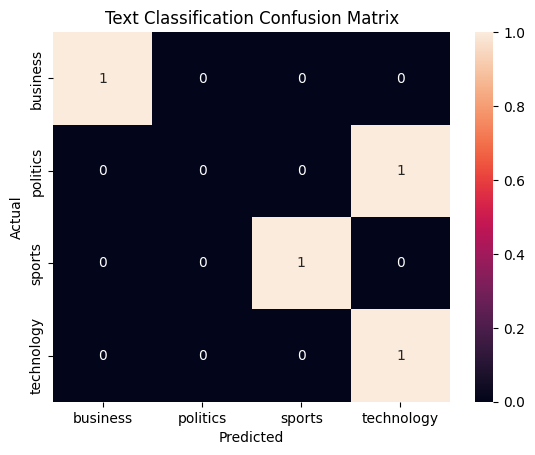

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Text Classification Confusion Matrix")

plt.show()

In [15]:
def classify_text(text):

    # Preprocess
    cleaned_text = preprocess_text(text)

    # Convert to TF-IDF
    text_tfidf = tfidf.transform([cleaned_text])

    # Predict category
    prediction = model.predict(text_tfidf)

    return prediction[0]

In [16]:
text = "The cricket team won the match"

result = classify_text(text)

print("Text:", text)
print("Category:", result)

Text: The cricket team won the match
Category: sports


In [17]:
texts = [

    "The football team won the championship",

    "The company released a new AI processor",

    "The government announced new election reforms",

    "The bank reported higher quarterly profits"
]

for text in texts:

    result = classify_text(text)

    print("\nText:", text)
    print("Category:", result)



Text: The football team won the championship
Category: sports

Text: The company released a new AI processor
Category: technology

Text: The government announced new election reforms
Category: politics

Text: The bank reported higher quarterly profits
Category: business
